In [1]:
import pandas as pd
import glob
from functools import reduce
import seaborn as sns

# 2026 revision: the Kaggle dataset (utkarshxy/who-worldhealth-statistics-2020-complete)
# was reformatted from pre-cleaned 2-column CSVs to raw WHO format. csv_clean/ holds the
# 2015 Both-sexes point estimates re-derived by verify_paper.py from the current raw
# csv_data/, so the original analysis logic below runs unchanged.
csv_list = glob.glob('csv_clean/*.csv')

wo_year = [pd.read_csv(f) for f in csv_list]

col_list = [k.columns[1] for k in wo_year]
print(*col_list, len(col_list), sep=", ")

for name, k in zip(col_list, wo_year):
    globals()[name] = k

LifeExp

cardio_cancer, alcohol, sanitation, drinking_water, handwash, birth_att_skilled, clean_fuel_tech, suicideRate, dentists, HALE, HepB, Malaria, TB, MR_infant_1y, NTD, LifeExp, doctors, MR_Poison, MR_infant_28d, HIV, nursing_mid, Pharmacists, safe_san, Tobacco, UHC_Cov, MR_infant_5y, 26


,Location,LifeExp
0,Afghanistan,61.65
1,Albania,77.84
2,Algeria,76.54
3,Angola,61.72
4,Antigua and Barbuda,76.14
...,...,...
178,Venezuela (Bolivarian Republic of),74.66
179,Viet Nam,73.16
180,Yemen,67.47
181,Zambia,60.50


In [2]:
# This merges the multiple CSV files ON 'Location' then drops Location column.
def new_list(df2list):
    df2 = reduce(lambda left,right: pd.merge(left,right,on='Location'), df2list)
    df2 = df2.drop(df2.columns[0], axis=1)
    return df2

# This helps to create Table with Descriptions on the correlation coefficients and sort by the strongest correlation
def corr_sort(df_corr):
    desc = []
    pn = []
    for value in df_corr[df_corr.columns[1]]:
        if 0 <= value < 0.10:
            desc.append("Negligible")
            pn.append("Positive")
        elif -0.10 < value <= 0:
            desc.append("Negligible")
            pn.append("Negative")
        elif 0.10 <= value < 0.40: 
            desc.append("Weak")
            pn.append("Positive")
        elif -0.40 < value <= -0.10:
            desc.append("Weak")
            pn.append("Negative")
        elif 0.40 <= value < 0.70: 
            desc.append("Moderate")
            pn.append("Positive")
        elif -0.70 < value <= -0.40:
            desc.append("Moderate")
            pn.append("Negative")
        elif 0.70 <= value < 0.90: 
            desc.append("Strong")
            pn.append("Positive")
        elif -0.90 < value <= -0.70:
            desc.append("Strong")
            pn.append("Negative")
        elif 0.90 <= value <= 1.00: 
            desc.append("Very Strong")
            pn.append("Positive")
        elif -1.00 <= value <= -0.90:
            desc.append("Very Strong")
            pn.append("Negative")
    df_corr["Interp."] = desc # col 2
    df_corr["+/-"] = pn  # col 3
    df_corr["sq"] = df_corr[df_corr.columns[1]]**2  # col 4
    df_corr = df_corr.sort_values(by=df_corr.columns[4], ascending=False)
    df_corr = df_corr.drop(df_corr.columns[4], axis=1)
    return df_corr

In [3]:
#Newborn and child mortality
NCM_l = [LifeExp, MR_infant_28d, MR_infant_1y, MR_infant_5y]
NCM = new_list(NCM_l)
#Communicable Diseases
CD_l = [LifeExp, Malaria, TB, HepB, NTD, HIV]
CD = new_list(CD_l)
#Noncommunicable diseases and mental health
NCD_l = [LifeExp, cardio_cancer, suicideRate]
NCD = new_list(NCD_l)
#Health Workforce
HW_l = [LifeExp, doctors, nursing_mid, dentists, Pharmacists]
HW = new_list(HW_l)
#Drinking Water
DW_l = [LifeExp, drinking_water, sanitation, safe_san, handwash]
DW = new_list(DW_l)
#Substance abuse / Tobacco control
AT_l = [LifeExp, alcohol, Tobacco]
AT = new_list(AT_l)
#universal health coverage (UHC)
UHC_l = [LifeExp, UHC_Cov]
UHC = new_list(UHC_l)
#Clean household energy
CHE_l = [LifeExp, clean_fuel_tech]
CHE = new_list(CHE_l)
#Mortality from environment pollution
POI_l = [LifeExp, MR_Poison]
POI = new_list(POI_l)

CD.corr()

,LifeExp,Malaria,TB,HepB,NTD,HIV
LifeExp,1.000000,-0.641488,-0.534313,-0.552436,-0.238661,-0.480869
Malaria,-0.641488,1.000000,0.131909,0.597746,0.245079,0.140975
TB,-0.534313,0.131909,1.000000,0.173861,0.158687,0.587582
HepB,-0.552436,0.597746,0.173861,1.000000,0.094683,0.105160
NTD,-0.238661,0.245079,0.158687,0.094683,1.000000,-0.031852
HIV,-0.480869,0.140975,0.587582,0.105160,-0.031852,1.000000


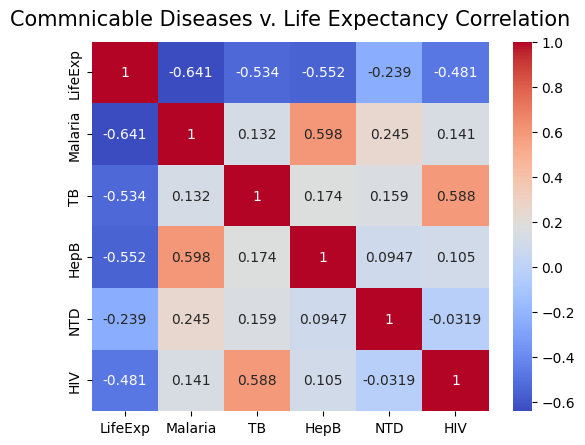

In [4]:
heatmap = sns.heatmap(CD.corr(),annot=True, fmt='.3g', cmap='coolwarm')
heatmap.set_title('Commnicable Diseases v. Life Expectancy Correlation', fontdict={'fontsize':15}, pad=12);

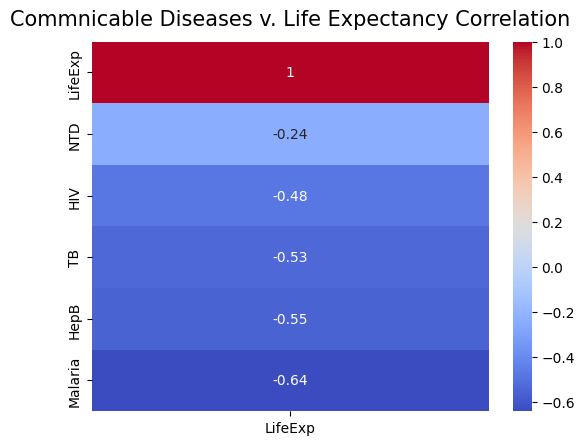

In [5]:
heatmap2 = sns.heatmap(CD.corr()[['LifeExp']].sort_values(by='LifeExp', ascending=False), annot=True, cmap='coolwarm')

heatmap2.set_title('Commnicable Diseases v. Life Expectancy Correlation', fontdict={'fontsize':15}, pad=12);

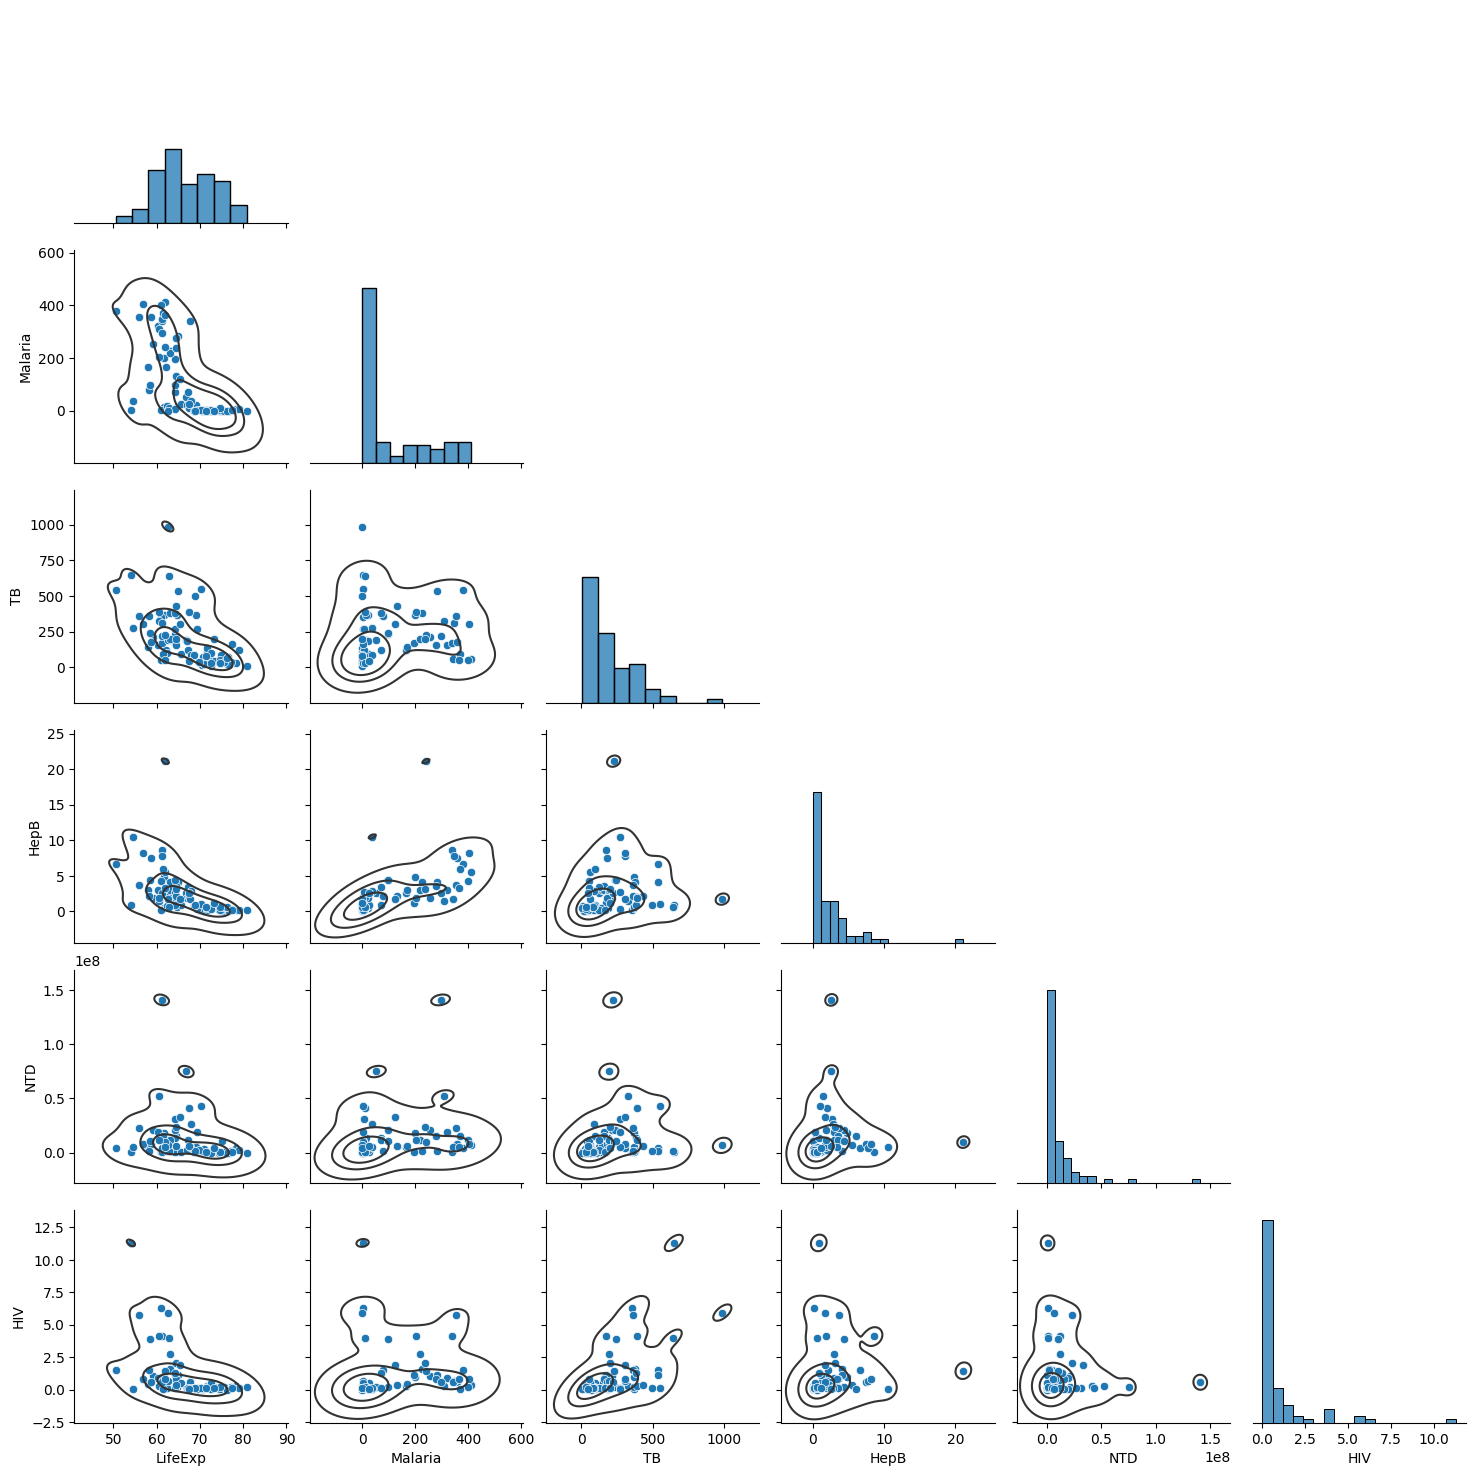

In [6]:
# kind{‘scatter’, ‘kde’, ‘hist’, ‘reg’} => plot_kws=dict()
# diag_kind{‘auto’, ‘hist’, ‘kde’, None} => diag_kws=dict()
# corner = True/False -> Triangle

x = sns.pairplot(CD, kind="scatter", diag_kind="hist",corner=True)
x.map_lower(sns.kdeplot, levels=4, color=".2")

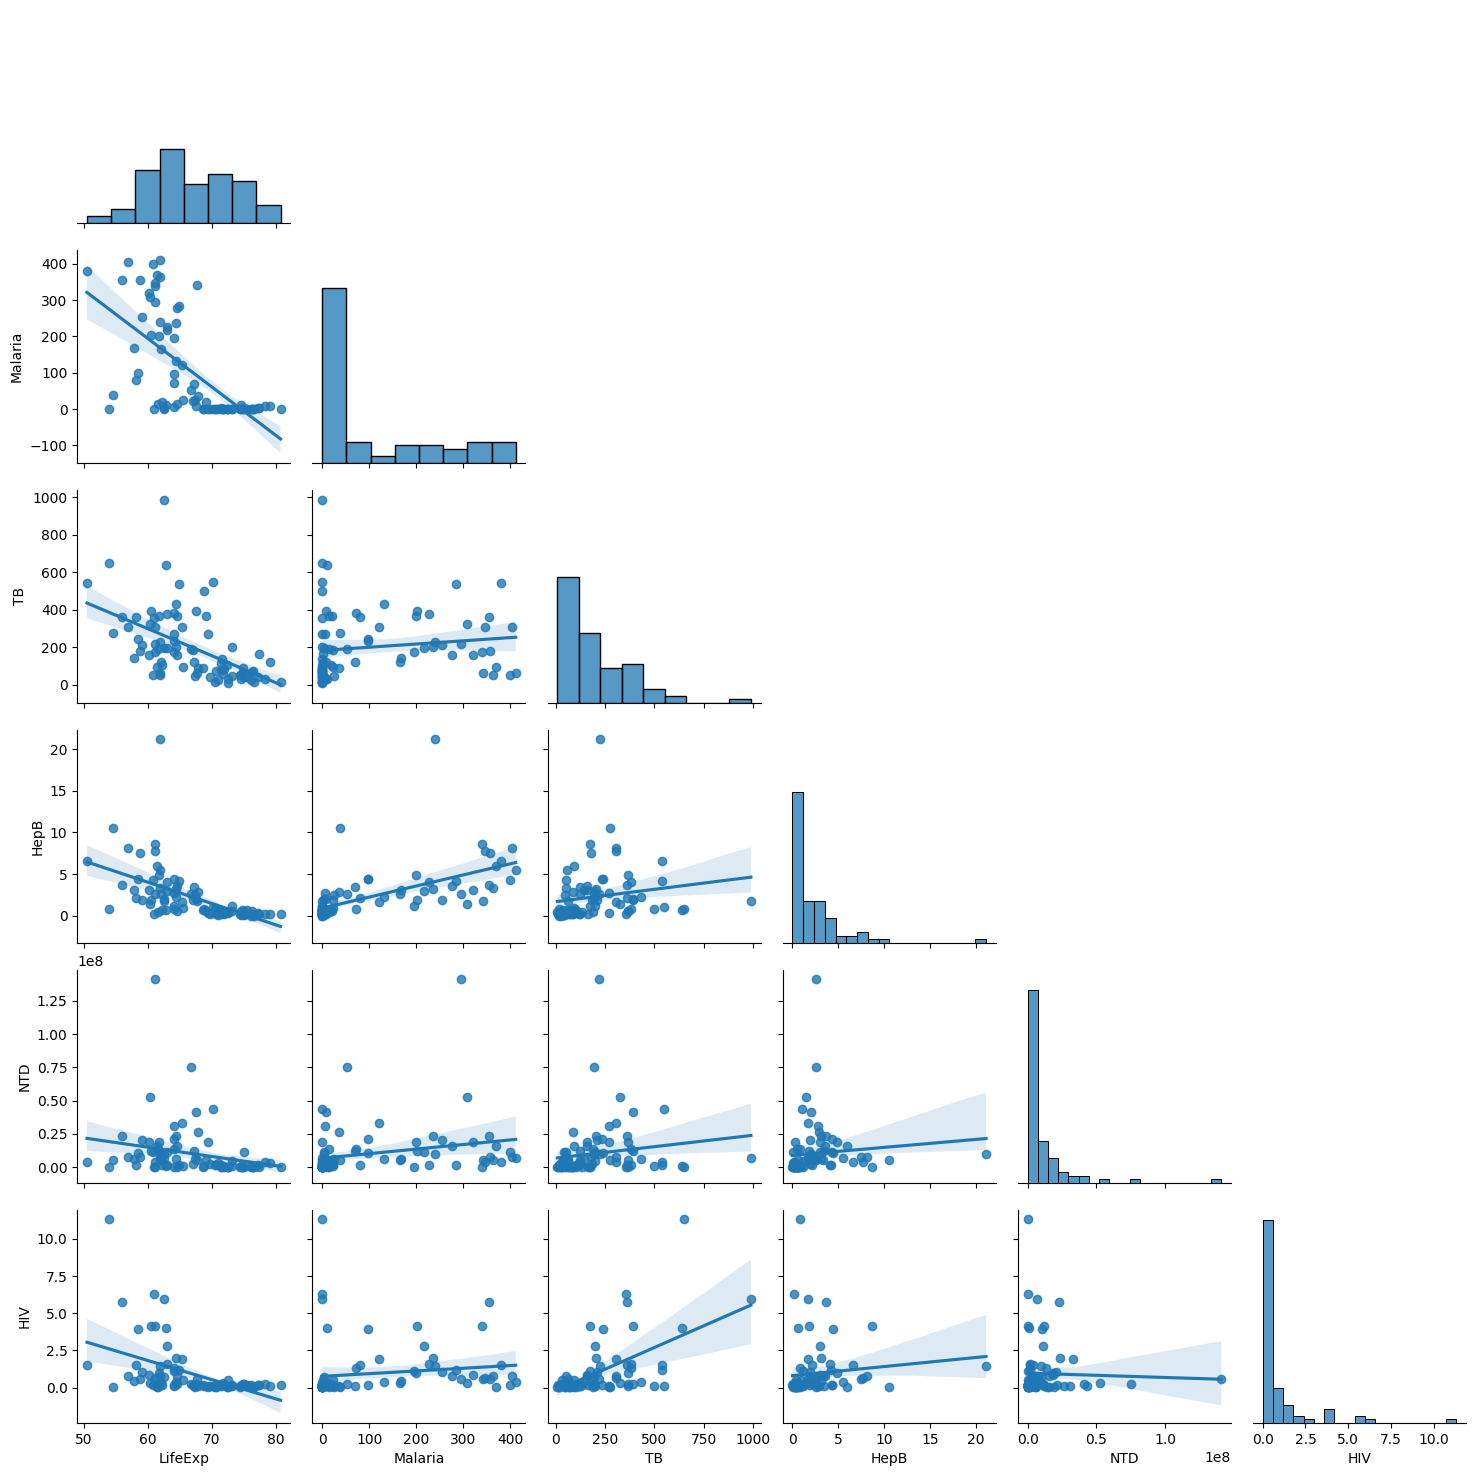

In [7]:
x = sns.pairplot(CD, kind="reg", diag_kind="hist",corner=True)

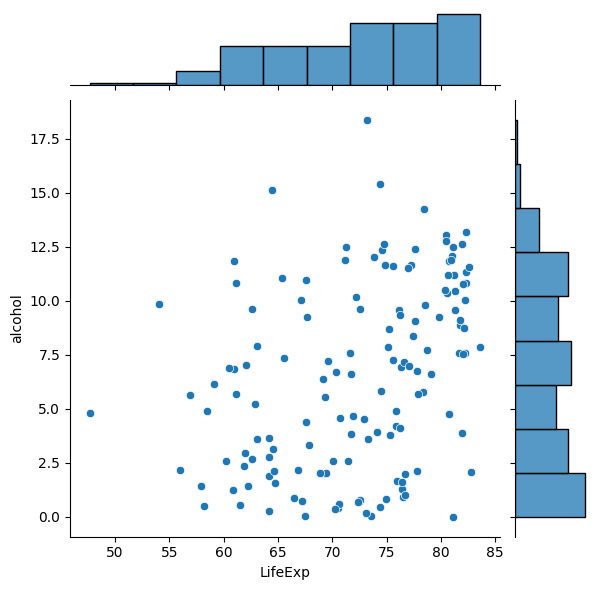

In [8]:
#sns.set_style("whitegrid")
sns.jointplot(x=AT["LifeExp"], y=AT["alcohol"],data=AT)


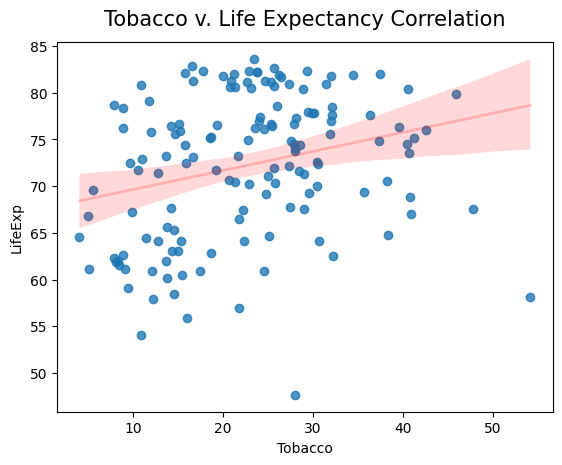

In [9]:
to_exp = sns.regplot(y=AT["LifeExp"], x=AT["Tobacco"], line_kws={"color":"r","alpha":0.2, "lw":2})
to_exp.set_title('Tobacco v. Life Expectancy Correlation', fontdict={'fontsize':15}, pad=12);

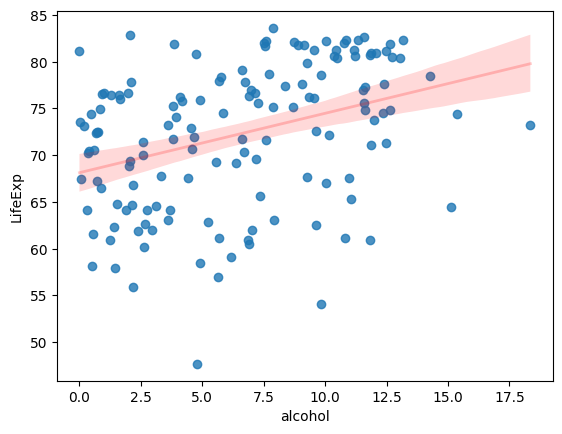

In [10]:
sns.regplot(y=AT["LifeExp"], x=AT["alcohol"], line_kws={"color":"r","alpha":0.2, "lw":2})
to_exp.set_title('Alcohol v. Life Expectancy Correlation', fontdict={'fontsize':15}, pad=12);

<Axes: xlabel='LifeExp', ylabel='Malaria'>

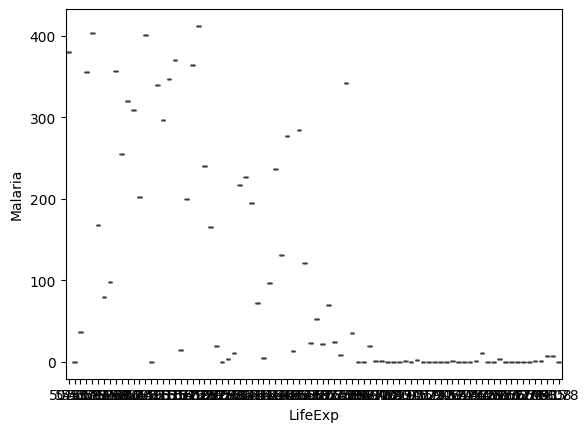

In [11]:
sns.boxplot(x=CD["LifeExp"], y=CD["Malaria"],data=CD)

<Axes: xlabel='LifeExp', ylabel='Malaria'>

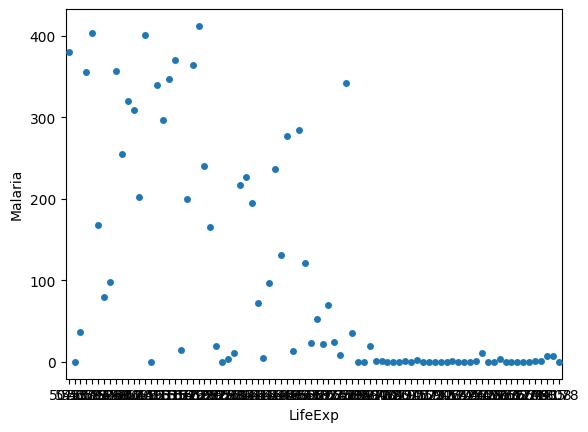

In [12]:
sns.swarmplot(x=CD["LifeExp"], y=CD["Malaria"],data=CD)

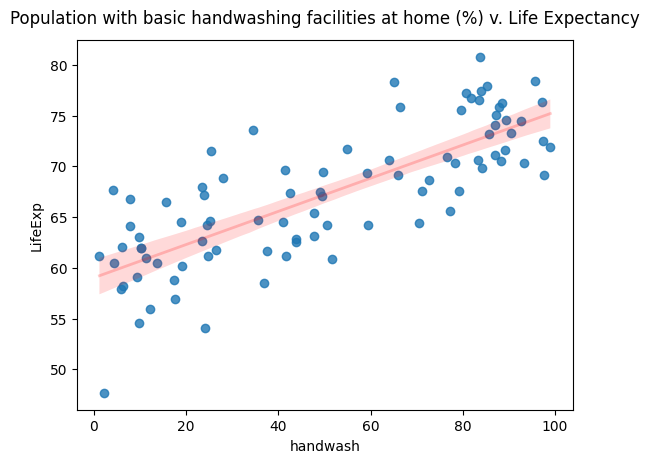

In [13]:
s = [LifeExp, handwash]
q = new_list(s)
#z = sns.pairplot(q, kind="reg", diag_kind="hist",corner=True)
z = sns.regplot(y=q["LifeExp"], x=q["handwash"], line_kws={"color":"r","alpha":0.2, "lw":2})
z.set_title('Population with basic handwashing facilities at home (%) v. Life Expectancy', fontdict={'fontsize':12}, pad=12);

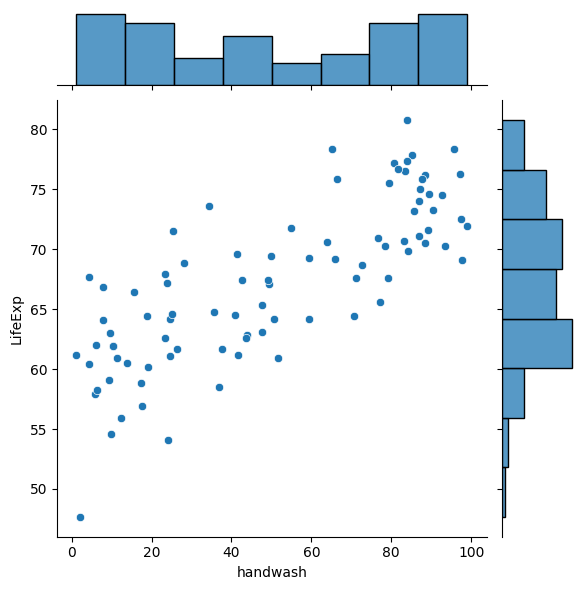

In [14]:

sns.jointplot(y=q["LifeExp"], x=q["handwash"],data=q)

In [15]:
#Combine Dataframe by Group ONE BY ONE
from functools import reduce
#-- Life Exp - Variable one -one --
Variable_List = [Malaria, TB, HepB, NTD, HIV, cardio_cancer, suicideRate, alcohol, Tobacco, MR_Poison, clean_fuel_tech, sanitation, drinking_water, handwash, safe_san,dentists, Pharmacists, nursing_mid, doctors, UHC_Cov, MR_infant_28d, MR_infant_1y, MR_infant_5y, birth_att_skilled]

corr_data =[]
name_data =[]
def name(data):
    name =[x for x in globals() if globals()[x] is data][0]
    return name

for var in Variable_List:
    df_t = pd.merge(LifeExp, var, how='inner', on='Location').drop(columns='Location')
    corr_t = df_t.corr()
    corr_t = corr_t.drop(corr_t.columns[[0]])
    corr_t = corr_t.drop(corr_t.columns[[1]],axis=1)
    corr_data.append(corr_t.iloc[0, 0])  # 2026 fix: pandas 3.0 treats iloc[0][0] inner int as label
    name_data.append(name(var))


DMS_concat = pd.DataFrame({'Variable':name_data, 'Correlation':corr_data})
DMS_concat

def color_positive_green(val):
    """
    Takes a scalar and returns a string with
    the css property `'color: green'` for positive
    strings, black otherwise.
    """
    if val == 'Negative':
        color = 'red'
    elif val == 'Positive':
        color = 'blue'
    else:
        color = 'black'
    return 'color: %s' % color

finalvar = corr_sort(DMS_concat)
finalvar.style.map(color_positive_green)  # 2026 fix: Styler element-wise styler was renamed to .map in pandas 3.0


,Variable,Correlation,Interp.,+/-
21,MR_infant_1y,-0.895958,Strong,Negative
22,k,-0.874980,Strong,Negative
20,MR_infant_28d,-0.871679,Strong,Negative
19,UHC_Cov,0.865219,Strong,Positive
11,sanitation,0.822244,Strong,Positive
12,drinking_water,0.814540,Strong,Positive
10,clean_fuel_tech,0.793851,Strong,Positive
9,MR_Poison,-0.787836,Strong,Negative
13,handwash,0.782170,Strong,Positive
14,safe_san,0.694502,Moderate,Positive
